In [331]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
import optuna
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.feature_selection import RFECV, mutual_info_classif


recall=  TP / (TP + FN)
precision = TP / (TP + FP)

In [332]:
with open('../../data/enhanced_trades_df_v2.pkl', 'rb') as f:
    trades = pickle.load(f)

In [333]:
# trades["random_feature"] = np.random.randn(len(trades))

In [334]:
trades

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,rsi,adx,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,75.574806,33.866604,...,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,0.0,0.171921,0.815166
1419,HINDALCO,2016-03-21,80.699150,2016-03-30,82.575851,2.325553,80.699150,0.009390,66.985118,30.847063,...,0.000358,-0.152065,33.855358,0.968967,0.063425,1,Metals & Mining,3.0,0.171921,0.512195
3240,TATASTEEL,2016-03-21,22.325666,2016-05-05,24.403414,9.306541,22.325666,0.004467,73.931740,30.156950,...,0.000155,-0.579234,35.126138,1.071643,0.016532,1,Metals & Mining,3.0,0.171921,0.512195
598,BHARTIARTL,2016-03-22,299.554504,2016-04-01,286.365204,-4.402972,299.554504,-0.007776,68.502922,30.521119,...,0.000175,0.457509,83.115273,1.333358,0.015242,0,Telecommunication,3.0,-0.170878,0.512195
2815,RELIANCE,2016-03-22,229.608643,2016-03-28,223.593719,-2.619641,229.608643,0.010171,67.560319,30.172319,...,0.000280,0.116702,80.890779,1.781608,0.113989,0,Oil Gas & Consumable Fuels,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,INDIGO,2025-08-27,6050.000000,2025-08-28,5727.000000,-5.338843,6050.000000,0.000000,57.705115,30.314948,...,0.000106,3.992301,603.398978,0.451727,0.000000,0,Services,1.0,-0.240706,0.744048
3580,VMM,2025-08-27,153.139999,2025-09-02,146.330002,-4.446910,153.139999,0.000000,68.060884,31.580026,...,0.000392,1.153450,218.252956,2.544196,0.000000,0,Consumer Services,1.0,0.189966,0.744048
3360,TITAN,2025-08-29,3628.800049,2025-09-15,3534.100098,-2.609677,3628.800049,-0.002447,64.093506,31.060234,...,0.000062,-0.379968,97.851273,1.078735,0.072640,0,Consumer Durables,1.0,0.183092,0.744048
2209,MFSL,2025-08-29,1602.199951,2025-09-04,1566.000000,-2.259390,1602.199951,-0.004041,53.859737,30.395963,...,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,Financial Services,1.0,-0.029508,0.744048


In [335]:
trades["return"].describe()

count    3669.000000
mean        2.615062
std        15.743259
min       -68.927544
25%        -3.666073
50%        -1.060605
75%         3.622118
max       359.561768
Name: return, dtype: float64

In [336]:
trades["result"] = np.where(trades["return"] > -1, 0, 1)

In [337]:
print(trades["result"].value_counts())

result
1    1861
0    1808
Name: count, dtype: int64


In [338]:
trades.columns

Index(['Symbol', 'entry_date', 'entry_price', 'exit_date', 'exit_price',
       'return', 'Close', 'stock_ret_1d', 'rsi', 'adx', 'Index_Close',
       'index_ret_1d', 'index_ret_5d', 'index_ret_20d', 'index_vol',
       'index_vol_5d', 'index_vol_20d', 'plus_di', 'minus_di', 'rsi_5_chg',
       'adx_5_chg', 'roc_5', 'atr_5_chg', 'vol_chg_5d', 'volatility_5d',
       '5_days_high', 'rsi_10_chg', 'adx_10_chg', 'roc_10', 'atr_10_chg',
       'vol_chg_10d', 'volatility_10d', '10_days_high', 'rsi_20_chg',
       'adx_20_chg', 'roc_20', 'atr_20_chg', 'vol_chg_20d', 'volatility_20d',
       '20_days_high', 'beta', 'corr', 'stock_vol', 'excess_vol',
       'volatility_of_volatility', 'dsv', 'vol_z', 'vol_vol_ratio', 'obv_z',
       'vwap_dev', 'result', 'Industry', 'hmm_cluster', 'Industry_woe',
       'cluster_win_loss_ratio'],
      dtype='object')

In [339]:
to_drop = ["Symbol", "entry_price", "exit_date","exit_price","Close","return" ,"Industry", "Index_Close", 'entry_date', '10_days_high', '20_days_high', '5_days_high','index_vol','stock_vol']

In [340]:
df= trades.drop(columns=to_drop)

In [341]:
df

,stock_ret_1d,rsi,adx,index_ret_1d,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,plus_di,minus_di,...,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,-0.015344,75.574806,33.866604,0.006212,0.042853,0.032008,0.008721,0.015809,42.862165,12.001263,...,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,0,0.0,0.171921,0.815166
1419,0.009390,66.985118,30.847063,0.013137,0.021953,0.068439,0.009521,0.011955,31.471365,16.168162,...,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,0,3.0,0.171921,0.512195
3240,0.004467,73.931740,30.156950,0.013137,0.021953,0.068439,0.009521,0.011955,31.415420,11.422246,...,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,0,3.0,0.171921,0.512195
598,-0.007776,68.502922,30.521119,0.001382,0.034086,0.066397,0.005619,0.011964,24.215227,6.557481,...,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,1,3.0,-0.170878,0.512195
2815,0.010171,67.560319,30.172319,0.001382,0.034086,0.066397,0.005619,0.011964,29.992586,11.015276,...,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,1,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,0.000000,57.705115,30.314948,-0.008544,-0.021942,-0.012900,0.006526,0.006253,24.629198,10.955127,...,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,1,1.0,-0.240706,0.744048
3580,0.000000,68.060884,31.580026,-0.008544,-0.021942,-0.012900,0.006526,0.006253,32.114406,9.375004,...,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,1,1.0,0.189966,0.744048
3360,-0.002447,64.093506,31.060234,-0.003022,-0.026188,-0.017228,0.005823,0.006257,32.793803,12.005358,...,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,1,1.0,0.183092,0.744048
2209,-0.004041,53.859737,30.395963,-0.003022,-0.026188,-0.017228,0.005823,0.006257,31.244059,14.836225,...,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,1,1.0,-0.029508,0.744048


In [342]:
df.columns.sort_values()

Index(['Industry_woe', 'adx', 'adx_10_chg', 'adx_20_chg', 'adx_5_chg',
       'atr_10_chg', 'atr_20_chg', 'atr_5_chg', 'beta',
       'cluster_win_loss_ratio', 'corr', 'dsv', 'excess_vol', 'hmm_cluster',
       'index_ret_1d', 'index_ret_20d', 'index_ret_5d', 'index_vol_20d',
       'index_vol_5d', 'minus_di', 'obv_z', 'plus_di', 'result', 'roc_10',
       'roc_20', 'roc_5', 'rsi', 'rsi_10_chg', 'rsi_20_chg', 'rsi_5_chg',
       'stock_ret_1d', 'vol_chg_10d', 'vol_chg_20d', 'vol_chg_5d',
       'vol_vol_ratio', 'vol_z', 'volatility_10d', 'volatility_20d',
       'volatility_5d', 'volatility_of_volatility', 'vwap_dev'],
      dtype='object')

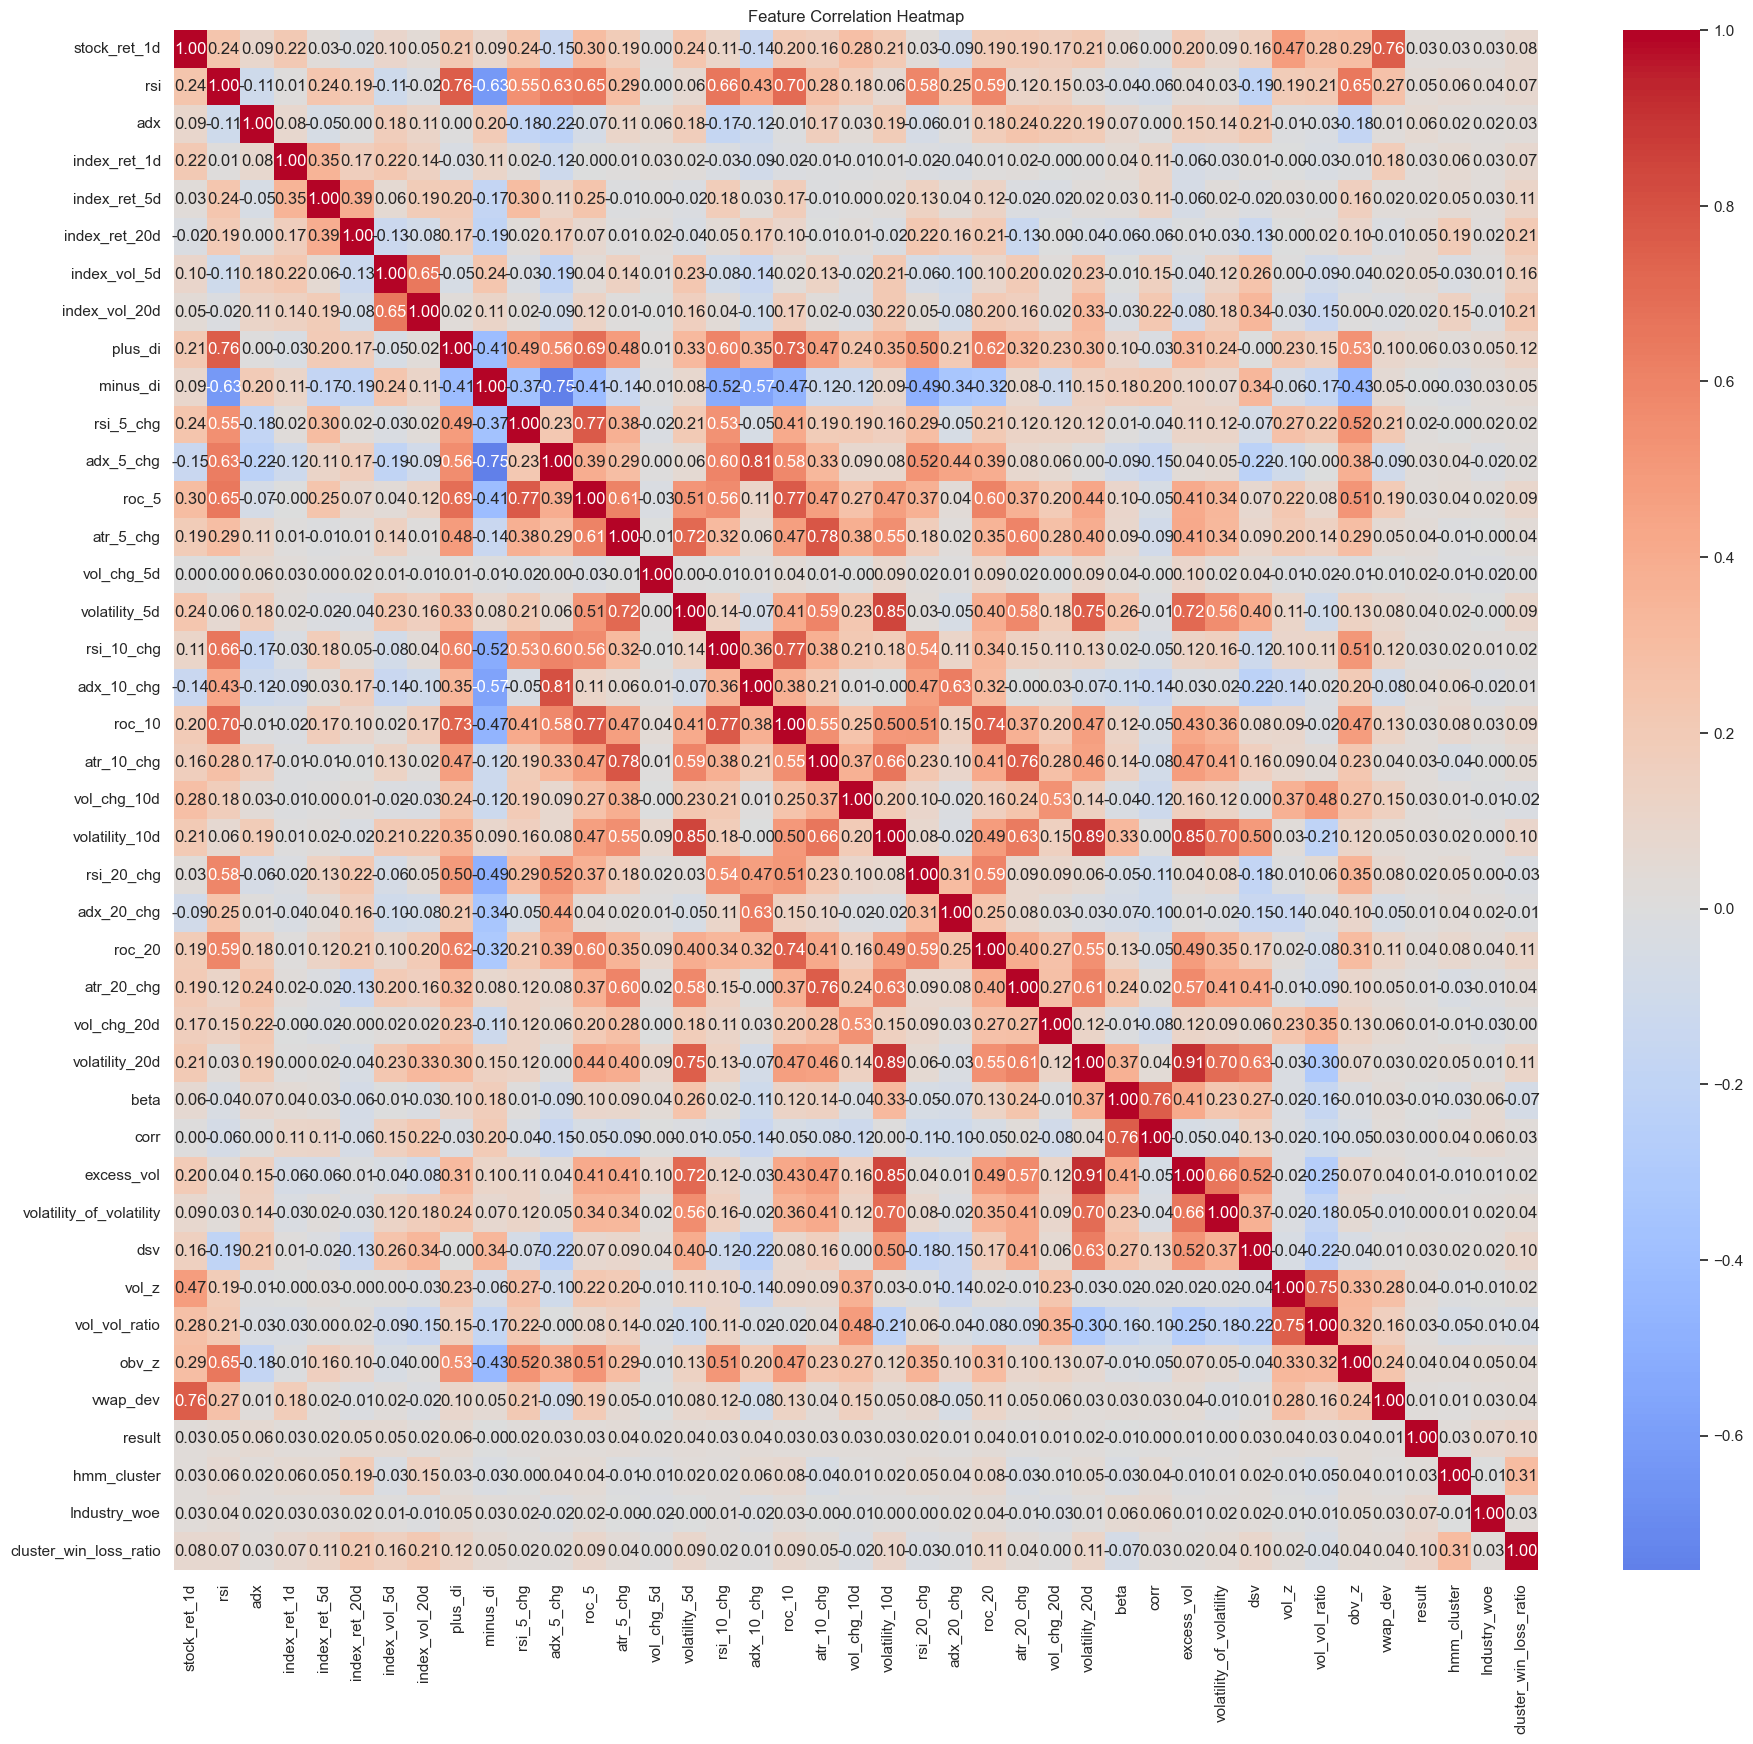

In [268]:
plt.figure(figsize=(22,20))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [343]:
temp = df.drop(columns=["result"], axis=1).copy()

In [344]:

categorical_features = ['hmm_cluster']

# Identify them in your feature matrix
discrete_features = temp.columns.isin(categorical_features)


mi = mutual_info_classif(temp, df["result"], discrete_features=discrete_features, random_state=42)
mi_series = pd.Series(mi, index=temp.columns).sort_values(ascending=False)
selected = mi_series[mi_series > mi_series.median()].index
X_filtered = temp[selected]

In [345]:
mi_series.sort_values(ascending=False)

index_ret_5d                0.046643
index_ret_20d               0.045761
index_ret_1d                0.036758
index_vol_5d                0.031110
index_vol_20d               0.028793
vol_chg_5d                  0.016261
plus_di                     0.014947
obv_z                       0.011244
Industry_woe                0.008183
volatility_20d              0.008036
vol_chg_10d                 0.007823
atr_5_chg                   0.006186
atr_10_chg                  0.005394
adx                         0.005220
roc_10                      0.005219
cluster_win_loss_ratio      0.004037
vol_chg_20d                 0.003587
hmm_cluster                 0.003364
roc_5                       0.003345
rsi_10_chg                  0.003115
stock_ret_1d                0.002225
rsi_20_chg                  0.001739
dsv                         0.000887
volatility_of_volatility    0.000758
minus_di                    0.000213
roc_20                      0.000134
corr                        0.000000
a

In [346]:
list(X_filtered.columns)

['index_ret_5d',
 'index_ret_20d',
 'index_ret_1d',
 'index_vol_5d',
 'index_vol_20d',
 'vol_chg_5d',
 'plus_di',
 'obv_z',
 'Industry_woe',
 'volatility_20d',
 'vol_chg_10d',
 'atr_5_chg',
 'atr_10_chg',
 'adx',
 'roc_10',
 'cluster_win_loss_ratio',
 'vol_chg_20d',
 'hmm_cluster',
 'roc_5',
 'rsi_10_chg']

In [347]:
temp

,stock_ret_1d,rsi,adx,index_ret_1d,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,plus_di,minus_di,...,excess_vol,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,-0.015344,75.574806,33.866604,0.006212,0.042853,0.032008,0.008721,0.015809,42.862165,12.001263,...,0.023462,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,0.0,0.171921,0.815166
1419,0.009390,66.985118,30.847063,0.013137,0.021953,0.068439,0.009521,0.011955,31.471365,16.168162,...,0.017277,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,3.0,0.171921,0.512195
3240,0.004467,73.931740,30.156950,0.013137,0.021953,0.068439,0.009521,0.011955,31.415420,11.422246,...,0.008765,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,3.0,0.171921,0.512195
598,-0.007776,68.502922,30.521119,0.001382,0.034086,0.066397,0.005619,0.011964,24.215227,6.557481,...,0.001272,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,3.0,-0.170878,0.512195
2815,0.010171,67.560319,30.172319,0.001382,0.034086,0.066397,0.005619,0.011964,29.992586,11.015276,...,0.000139,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,0.000000,57.705115,30.314948,-0.008544,-0.021942,-0.012900,0.006526,0.006253,24.629198,10.955127,...,0.006613,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,1.0,-0.240706,0.744048
3580,0.000000,68.060884,31.580026,-0.008544,-0.021942,-0.012900,0.006526,0.006253,32.114406,9.375004,...,0.011088,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,1.0,0.189966,0.744048
3360,-0.002447,64.093506,31.060234,-0.003022,-0.026188,-0.017228,0.005823,0.006257,32.793803,12.005358,...,0.002487,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,1.0,0.183092,0.744048
2209,-0.004041,53.859737,30.395963,-0.003022,-0.026188,-0.017228,0.005823,0.006257,31.244059,14.836225,...,0.006780,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,1.0,-0.029508,0.744048


In [348]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rfecv = RFECV(rf, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
rfecv.fit(X_filtered, df["result"])

RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
      estimator=RandomForestClassifier(n_estimators=200, random_state=42),
      n_jobs=-1, scoring='roc_auc')

In [350]:
best_features = X_filtered.columns[rfecv.support_]
print("Best subset:", best_features)

Best subset: Index(['index_ret_5d', 'index_ret_20d', 'index_ret_1d', 'index_vol_5d',
       'index_vol_20d', 'vol_chg_5d', 'plus_di', 'obv_z', 'Industry_woe',
       'volatility_20d', 'vol_chg_10d', 'atr_5_chg', 'atr_10_chg', 'adx',
       'roc_10', 'vol_chg_20d', 'roc_5', 'rsi_10_chg'],
      dtype='object')


In [207]:
cols = [
       'atr_10_chg', 'atr_20_chg',
    'index_ret_5d', 'index_ret_20d', 'index_vol_5d', 'index_vol_20d', 'vol_chg_10d', 'vol_chg_20d', 'vol_chg_5d', 'volatility_10d', 'volatility_20d','hmm_cluster',
    'result' ]

In [351]:
df = df[list(best_features) + ['result']]

In [352]:
df.columns

Index(['index_ret_5d', 'index_ret_20d', 'index_ret_1d', 'index_vol_5d',
       'index_vol_20d', 'vol_chg_5d', 'plus_di', 'obv_z', 'Industry_woe',
       'volatility_20d', 'vol_chg_10d', 'atr_5_chg', 'atr_10_chg', 'adx',
       'roc_10', 'vol_chg_20d', 'roc_5', 'rsi_10_chg', 'result'],
      dtype='object')

In [353]:
# X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["result"]), df["result"], test_size=0.2, random_state=42, stratify=df["result"])

# get first 80% of rows as training set and last 20% as test set
train_size = int(0.8 * len(df))
X_train = df.drop(columns=["result"]).iloc[:train_size]
X_test = df.drop(columns=["result"]).iloc[train_size:]
y_train = df["result"].iloc[:train_size]
y_test = df["result"].iloc[train_size:]

In [354]:
X_train

,index_ret_5d,index_ret_20d,index_ret_1d,index_vol_5d,index_vol_20d,vol_chg_5d,plus_di,obv_z,Industry_woe,volatility_20d,vol_chg_10d,atr_5_chg,atr_10_chg,adx,roc_10,vol_chg_20d,roc_5,rsi_10_chg
2396,0.042853,0.032008,0.006212,0.008721,0.015809,0.059312,42.862165,1.863594,0.171921,0.039271,-0.597268,0.153988,0.165470,33.866604,15.103111,0.814865,12.924772,0.186468
1419,0.021953,0.068439,0.013137,0.009521,0.011955,0.855372,31.471365,0.968967,0.171921,0.029232,-0.221978,-0.018998,-0.022858,30.847063,8.312333,1.037568,1.295639,0.008636
3240,0.021953,0.068439,0.013137,0.009521,0.011955,0.271385,31.415420,1.071643,0.171921,0.020720,-0.383685,-0.093495,-0.159776,30.156950,5.198421,-0.165259,2.308727,0.004306
598,0.034086,0.066397,0.001382,0.005619,0.011964,0.916172,24.215227,1.333358,-0.170878,0.013236,0.848752,0.059412,-0.010878,30.521119,5.852205,0.280783,2.333076,0.134275
2815,0.034086,0.066397,0.001382,0.005619,0.011964,0.462028,29.992586,1.781608,0.041870,0.012103,0.159604,-0.068499,-0.131682,30.172319,3.178954,0.200661,3.836131,0.074886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3666,-0.002774,-0.020814,0.001896,0.003874,0.004556,0.159383,15.770438,-0.570426,-0.119259,0.011990,-0.203771,-0.026385,-0.010596,38.176930,-1.511737,0.251261,-2.911356,-0.201497
368,-0.002774,-0.020814,0.001896,0.003874,0.004556,-0.485737,19.216169,-0.999341,-0.119259,0.012191,-0.589547,-0.106885,-0.112041,34.814486,-4.915970,-0.193926,-1.643626,-0.300429
1587,-0.004966,-0.019566,0.000248,0.003560,0.004565,2.002261,33.626873,1.796365,-0.170878,0.030363,1.326960,0.232574,0.165649,30.190714,16.025641,2.562465,16.025641,0.506935
644,-0.006855,-0.013968,-0.004840,0.003904,0.004096,0.587746,39.707052,2.949174,0.092264,0.032283,5.179753,0.066386,0.325860,30.236547,21.371377,1.390913,12.633532,0.333675


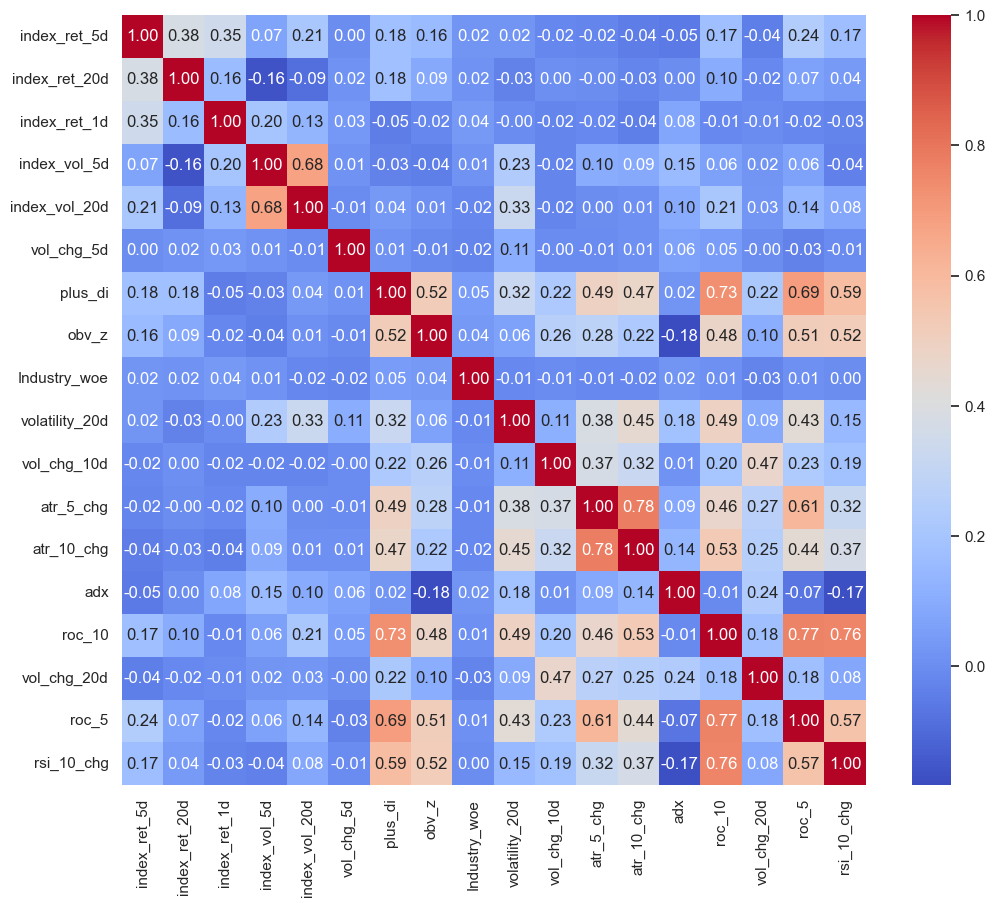

In [355]:
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap="coolwarm");

In [356]:
# one_hot_cols = ["hmm_cluster"]
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# train_ohe = ohe.fit_transform(X_train[one_hot_cols])
# test_ohe = ohe.transform(X_test[one_hot_cols])

# train_ohe_df = pd.DataFrame(train_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
# test_ohe_df = pd.DataFrame(test_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

# X_train_ohe = pd.concat([X_train.drop(columns=one_hot_cols), train_ohe_df], axis=1)
# X_test_ohe = pd.concat([X_test.drop(columns=one_hot_cols), test_ohe_df], axis=1)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [357]:
X_train_scaled

,index_ret_5d,index_ret_20d,index_ret_1d,index_vol_5d,index_vol_20d,vol_chg_5d,plus_di,obv_z,Industry_woe,volatility_20d,vol_chg_10d,atr_5_chg,atr_10_chg,adx,roc_10,vol_chg_20d,roc_5,rsi_10_chg
2396,1.877263,-0.046592,0.503931,0.283342,1.781101,-0.018683,1.589938,0.442689,1.219302,1.749384,-0.386279,0.410450,0.174450,0.588947,0.714090,-0.104753,1.203031,0.026450
1419,0.707917,1.010940,1.387083,0.457729,0.888440,-0.018522,-0.088678,-0.503015,1.219302,0.768509,-0.320185,-0.625190,-0.706792,-0.344630,-0.058494,-0.081846,-0.569930,-0.658068
3240,0.707917,1.010940,1.387083,0.457729,0.888440,-0.018640,-0.096922,-0.394476,1.219302,-0.063207,-0.348664,-1.071189,-1.347470,-0.557998,-0.412763,-0.205568,-0.415476,-0.674734
598,1.386718,0.951642,-0.112020,-0.393152,0.890383,-0.018509,-1.157985,-0.117820,-1.210061,-0.794488,-0.131614,-0.155763,-0.650734,-0.445405,-0.338382,-0.159688,-0.411763,-0.174451
2815,1.386718,0.951642,-0.112020,-0.393152,0.890383,-0.018601,-0.306599,0.356022,0.297653,-0.905197,-0.252983,-0.921546,-1.216010,-0.553247,-0.642517,-0.167929,-0.182610,-0.403054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3666,-0.675532,-1.579888,-0.046543,-0.773764,-0.825596,-0.018663,-2.402459,-2.130293,-0.844248,-0.916159,-0.316979,-0.669416,-0.649413,1.921607,-1.176175,-0.162725,-1.211322,-1.466918
368,-0.675532,-1.579888,-0.046543,-0.773764,-0.825596,-0.018793,-1.894676,-2.583696,-0.844248,-0.896547,-0.384920,-1.151354,-1.124106,0.882011,-1.563473,-0.208516,-1.018046,-1.847733
1587,-0.798170,-1.543662,-0.256671,-0.842265,-0.823482,-0.018289,0.228971,0.371621,-1.210061,0.878962,-0.047395,0.880932,0.175288,-0.547559,0.819046,0.075003,1.675785,1.260007
644,-0.903889,-1.381176,-0.905602,-0.767188,-0.932092,-0.018576,1.124982,1.590246,0.654786,1.066556,0.631139,-0.114012,0.924965,-0.533389,1.427228,-0.045501,1.158629,0.593087


In [358]:
# calculate class weights
class_weights = y_train.value_counts(normalize=True)
class_weights = {cls: 1/weight for cls, weight in class_weights.items()}
class_weights

{1: 1.9618983957219251, 0: 2.0396108408617097}

In [359]:
# class_weights = {0: 1, 1: 1.2}

In [360]:
class_weights[0]

2.0396108408617097

In [361]:
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((2935, 18), (734, 18), (2935,), (734,))

In [362]:
def y_train_shuffle(random_state=42):
    return y_train.sample(frac=1, random_state=random_state).reset_index(drop=True).copy()

# Logistic Regression

In [363]:
# optuna for logistic regression
def objective(trial):
    # Define the hyperparameters to tune
    C = trial.suggest_float('C', 1e-5, 10.0, log=True)
    
    # Create the model with the suggested hyperparameters
    model = LogisticRegression(C=C,  class_weight=class_weights, random_state=42, max_iter=1000)
    
    # Perform cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='f1')
    
    # Return the average F1 score across folds
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-10-09 02:57:52,963] A new study created in memory with name: no-name-4ac7ddd5-100d-4065-a6ae-e470afaa485b
[I 2025-10-09 02:57:52,986] Trial 0 finished with value: 0.5496435571898282 and parameters: {'C': 0.4861925649720914}. Best is trial 0 with value: 0.5496435571898282.
[I 2025-10-09 02:57:53,005] Trial 1 finished with value: 0.5496942203269393 and parameters: {'C': 0.12848251759218732}. Best is trial 1 with value: 0.5496942203269393.
[I 2025-10-09 02:57:53,020] Trial 2 finished with value: 0.5508797368239812 and parameters: {'C': 0.00289864317323964}. Best is trial 2 with value: 0.5508797368239812.
[I 2025-10-09 02:57:53,034] Trial 3 finished with value: 0.550813279355394 and parameters: {'C': 0.0035507171389069624}. Best is trial 2 with value: 0.5508797368239812.
[I 2025-10-09 02:57:53,060] Trial 4 finished with value: 0.5441528744568188 and parameters: {'C': 0.00026060385301861336}. Best is trial 2 with value: 0.5508797368239812.
[I 2025-10-09 02:57:53,076] Trial 5 finishe

Best trial:
  Value: 0.5565015942046315
  Params: 
    C: 0.0008749514147339288


              precision    recall  f1-score   support

           0       0.59      0.43      0.50       369
           1       0.55      0.70      0.61       365

    accuracy                           0.56       734
   macro avg       0.57      0.56      0.56       734
weighted avg       0.57      0.56      0.55       734



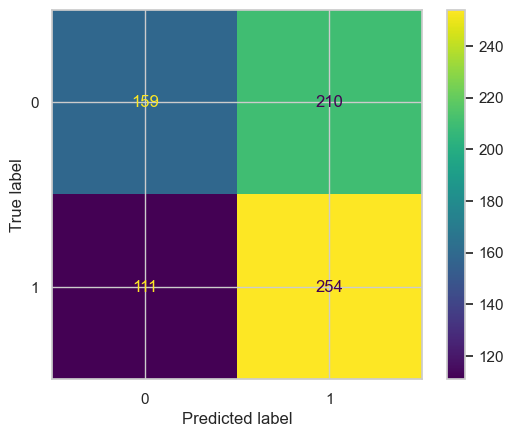

In [364]:
lr = LogisticRegression(class_weight=class_weights, random_state=42, max_iter=1000, C=trial.params['C'])
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot()
plt.show()

In [371]:
y_probs = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_thresh = (y_probs >= 0.52).astype(int)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.53      0.69      0.60       369
           1       0.55      0.38      0.45       365

    accuracy                           0.54       734
   macro avg       0.54      0.53      0.52       734
weighted avg       0.54      0.54      0.52       734



In [366]:
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

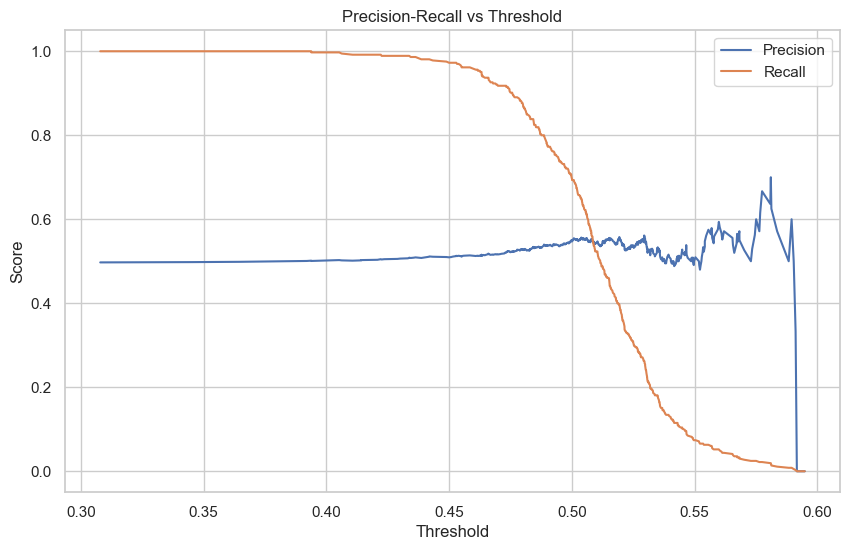

In [367]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

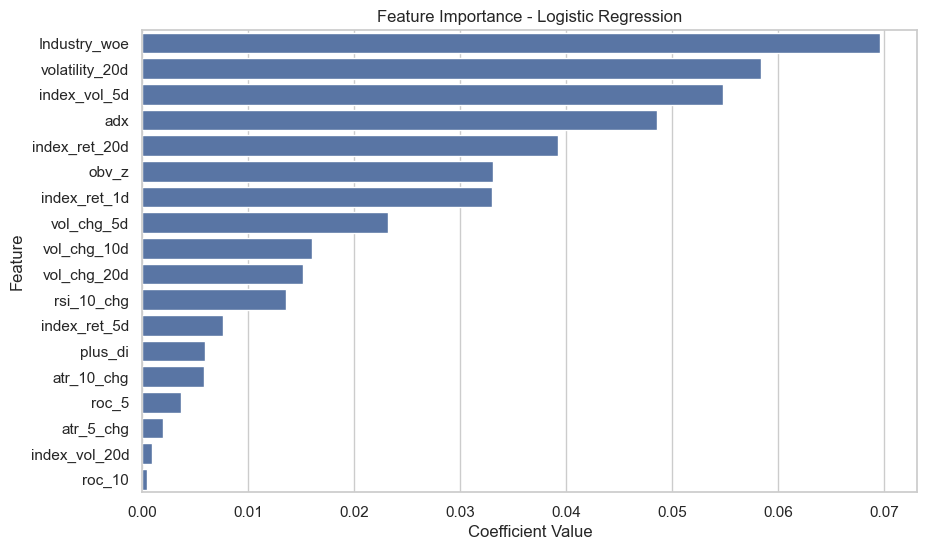

In [372]:
# feature importance
feat_importance = pd.Series(lr.coef_[0], index=X_train_scaled.columns)
feat_importance = feat_importance.abs()
feat_importance = feat_importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

# XGBoost

In [373]:
def objective_xgb(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 32),
          'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': class_weights[1] / class_weights[0]  # handle class imbalance
    }
    
    model = XGBClassifier(**param, random_state=42, n_jobs=-1)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    return f1

In [374]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, n_jobs=-1)
print("Best trial:")
trial = study_xgb.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-10-09 03:01:37,546] A new study created in memory with name: no-name-b2b522b7-9dc1-4af9-be5d-781604f71761
[I 2025-10-09 03:01:42,881] Trial 4 finished with value: 0.5521628498727735 and parameters: {'max_depth': 5, 'learning_rate': 0.07705890896869731, 'n_estimators': 124, 'subsample': 0.5703654216616121, 'colsample_bytree': 0.9434272783518286}. Best is trial 4 with value: 0.5521628498727735.
[I 2025-10-09 03:01:49,402] Trial 15 finished with value: 0.5329883570504528 and parameters: {'max_depth': 22, 'learning_rate': 0.21087581682076462, 'n_estimators': 77, 'subsample': 0.9149506600986874, 'colsample_bytree': 0.5585668243020081}. Best is trial 4 with value: 0.5521628498727735.
[I 2025-10-09 03:01:52,471] Trial 3 finished with value: 0.5556978233034571 and parameters: {'max_depth': 7, 'learning_rate': 0.10295097580745874, 'n_estimators': 258, 'subsample': 0.605395458767878, 'colsample_bytree': 0.9296233460154627}. Best is trial 3 with value: 0.5556978233034571.
[I 2025-10-09 03

Best trial:
  Value: 0.5788819875776398
  Params: 
    max_depth: 26
    learning_rate: 0.019026868140174177
    n_estimators: 320
    subsample: 0.7573314082450564
    colsample_bytree: 0.5539969287875606


              precision    recall  f1-score   support

           0       0.51      0.39      0.44       369
           1       0.50      0.61      0.55       365

    accuracy                           0.50       734
   macro avg       0.50      0.50      0.50       734
weighted avg       0.50      0.50      0.50       734



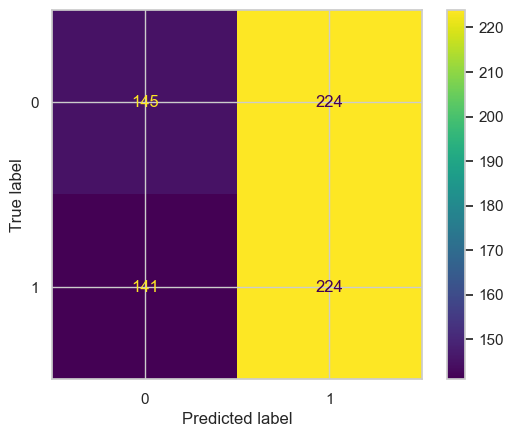

CPU times: user 2.41 s, sys: 21.9 s, total: 24.3 s
Wall time: 3.53 s


In [375]:
%%time
xgb = XGBClassifier(**trial.params, random_state=42, n_jobs=-1)
# xgb = XGBClassifier(scale_pos_weight=class_weights[1]/class_weights[0], n_estimators=50, learning_rate=0.2450478621569601, random_state=42, n_jobs=-1, max_depth=3,  eval_metric= 'logloss')
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot()
plt.show()

In [376]:
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

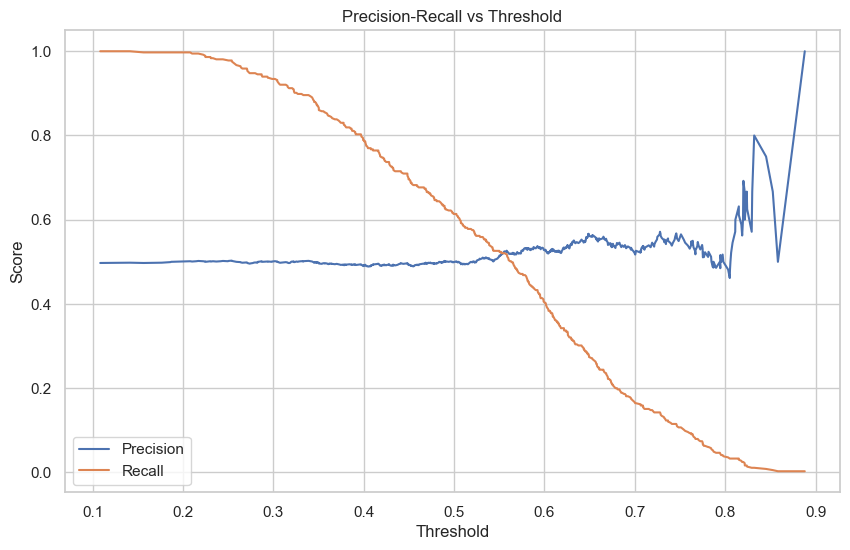

In [377]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [382]:
y_probs = xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_thresh = (y_probs >= 0.65).astype(int)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.52      0.79      0.63       369
           1       0.56      0.27      0.37       365

    accuracy                           0.53       734
   macro avg       0.54      0.53      0.50       734
weighted avg       0.54      0.53      0.50       734



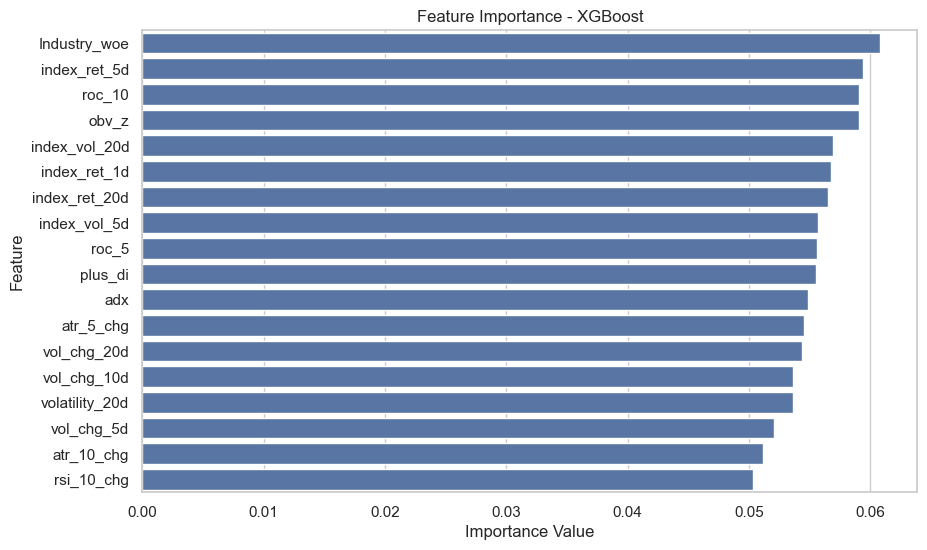

In [378]:
# feature importance xgb
feat_importance = pd.Series(xgb.feature_importances_, index=X_train_scaled.columns)
feat_importance = feat_importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Value")
plt.ylabel("Feature")
plt.show()